# Exploratory Data Analysis of Large-Scale Industry Performance Dataset

## Internship Project

### Objective
To perform univariate, bivariate, and multivariate analysis on an industry performance dataset and extract meaningful business insights using statistical techniques and visualizations.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, zscore

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, zscore

## Insight

The required Python libraries were imported successfully for data manipulation, statistical analysis, and visualization.

In [43]:
df = pd.read_csv('Industry.csv')

In [44]:
df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


## Insight

The dataset contains company-level information from multiple industries and regions. Key business variables include employee count, annual revenue, profit margin, customer count, and market ratings, which can be used to evaluate organizational performance and market presence.

In [45]:
df.shape

(15000, 12)

## Insight

The dataset contains 15,000 records and 12 attributes. The large number of observations makes the dataset suitable for comprehensive statistical analysis and business intelligence studies.

In [46]:
df.columns

Index(['id', 'company_name', 'industry', 'country', 'employee_count',
       'annual_revenue_million', 'profit_margin_percent', 'founded_year',
       'customer_count', 'market_rating', 'created_date', 'region'],
      dtype='str')

## Insight

The dataset contains company details, financial performance metrics, customer statistics, market ratings, and geographical information. These variables provide a complete view of industry performance across different sectors and regions.

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  str    
 2   industry                15000 non-null  str    
 3   country                 15000 non-null  str    
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  str    
 11  region                  15000 non-null  str    
dtypes: float64(3), int64(4), str(5)
memory usage: 1.4 MB


## Insight

The dataset contains 15,000 records and 12 variables. There are 7 numerical variables and 5 categorical variables. All columns contain 15,000 non-null values, indicating that the dataset is complete and does not contain missing data.

In [48]:
df.describe()

,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2606.862067,549.732707,25.012019,2004.374000,50449.251867,2.513780
std,4330.271354,1430.562513,288.244128,11.526187,8.606687,28744.638830,1.447998
min,1.000000,100.000000,50.160000,5.000000,1990.000000,500.000000,0.000000
25%,3750.750000,1379.000000,299.915000,15.050000,1997.000000,25676.250000,1.200000
50%,7500.500000,2587.000000,543.920000,24.910000,2004.000000,50726.500000,2.500000
75%,11250.250000,3839.000000,797.570000,35.100000,2012.000000,75271.250000,3.800000
max,15000.000000,5099.000000,1049.960000,45.000000,2019.000000,100495.000000,5.000000


## Insight

The average employee count is approximately 2,607 employees per company. The average annual revenue is around 549.73 million, while the average profit margin is 25.01%. Customer counts vary significantly across companies, indicating differences in business scale and market reach.

In [49]:
df.isnull().sum()

id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

## Insight

No missing values were found in the dataset. Since all columns contain complete information, no missing value treatment is required before performing further analysis.

In [50]:
df.duplicated().sum()

np.int64(0)

## Insight

No duplicate records were found in the dataset. This indicates that each company record is unique and the dataset is already consistent for further analysis.

In [51]:
df.drop_duplicates(inplace=True)

In [52]:
df['created_date'] = pd.to_datetime(df['created_date'])

C:\Users\swati\AppData\Local\Temp\ipykernel_13208\3129461750.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['created_date'] = pd.to_datetime(df['created_date'])


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      15000 non-null  int64         
 1   company_name            15000 non-null  str           
 2   industry                15000 non-null  str           
 3   country                 15000 non-null  str           
 4   employee_count          15000 non-null  int64         
 5   annual_revenue_million  15000 non-null  float64       
 6   profit_margin_percent   15000 non-null  float64       
 7   founded_year            15000 non-null  int64         
 8   customer_count          15000 non-null  int64         
 9   market_rating           15000 non-null  float64       
 10  created_date            15000 non-null  datetime64[us]
 11  region                  15000 non-null  str           
dtypes: datetime64[us](1), float64(3), int64(4), str(4)
memory

## Insight

Since no duplicate records were present in the dataset, no rows were removed during the duplicate handling process.

# Univariate Analysis

## Statistical Analysis of Numerical Variables

In [54]:
numerical_cols = [
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'founded_year',
    'customer_count',
    'market_rating'
]

numerical_cols

['employee_count',
 'annual_revenue_million',
 'profit_margin_percent',
 'founded_year',
 'customer_count',
 'market_rating']

## Insight

Univariate analysis was performed to understand the statistical characteristics of individual numerical variables. Measures such as mean, median, standard deviation, minimum, and maximum values help evaluate company performance and business scale.

In [55]:
for col in numerical_cols:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Standard Deviation:", df[col].std())
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


 employee_count
Mean: 2606.8620666666666
Median: 2587.0
Standard Deviation: 1430.5625126902273
Minimum: 100
Maximum: 5099

 annual_revenue_million
Mean: 549.7327066666667
Median: 543.9200000000001
Standard Deviation: 288.24412840517317
Minimum: 50.16
Maximum: 1049.96

 profit_margin_percent
Mean: 25.01201933333333
Median: 24.91
Standard Deviation: 11.526186847110734
Minimum: 5.0
Maximum: 45.0

 founded_year
Mean: 2004.374
Median: 2004.0
Standard Deviation: 8.606687070963435
Minimum: 1990
Maximum: 2019

 customer_count
Mean: 50449.251866666666
Median: 50726.5
Standard Deviation: 28744.63883020963
Minimum: 500
Maximum: 100495

 market_rating
Mean: 2.5137799999999997
Median: 2.5
Standard Deviation: 1.4479976604775011
Minimum: 0.0
Maximum: 5.0


## Skewness Analysis

In [56]:
for col in numerical_cols:
    print(col, ":", skew(df[col]))

employee_count : 0.0023532837281356905
annual_revenue_million : 0.027338494990466998
profit_margin_percent : 0.0025600913990232784
founded_year : 0.020602789755811004
customer_count : -0.004865441117368913
market_rating : -0.020031465411877128


## Insight

The skewness values are very close to zero for all numerical variables, indicating that the data distributions are approximately symmetric. This suggests that the dataset does not exhibit significant positive or negative skewness and is well-balanced for statistical analysis.

In [57]:
for col in numerical_cols:
    print(col, ":", kurtosis(df[col]))

employee_count : -1.1876991675841688
annual_revenue_million : -1.1870634023152409
profit_margin_percent : -1.20256527476831
founded_year : -1.1896124321980361
customer_count : -1.1947153719090147
market_rating : -1.2057588701018218


## Insight

All numerical variables show negative kurtosis values, indicating platykurtic distributions. This means the data has lighter tails and fewer extreme values compared to a normal distribution, suggesting a lower likelihood of significant outliers.

# Histogram Analysis

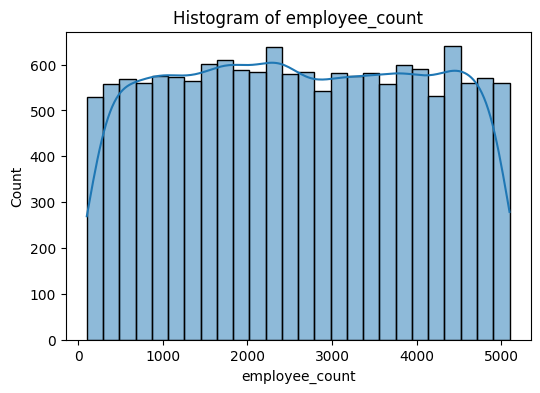

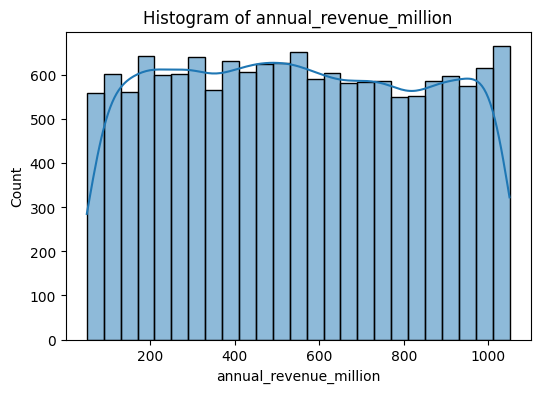

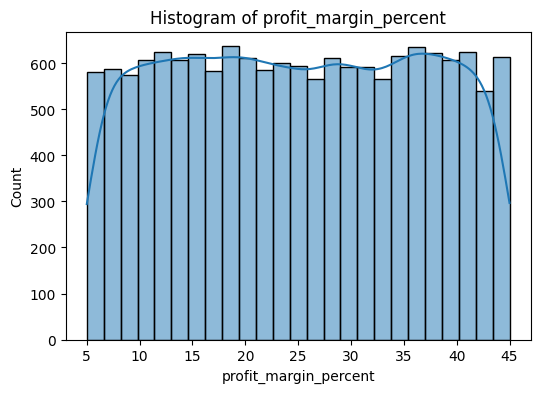

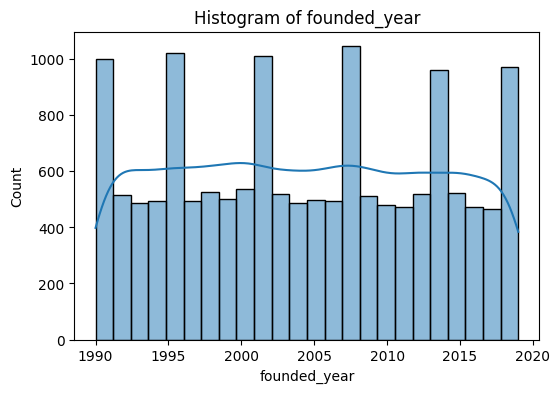

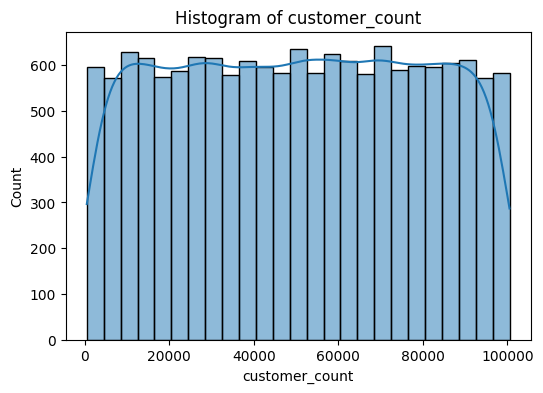

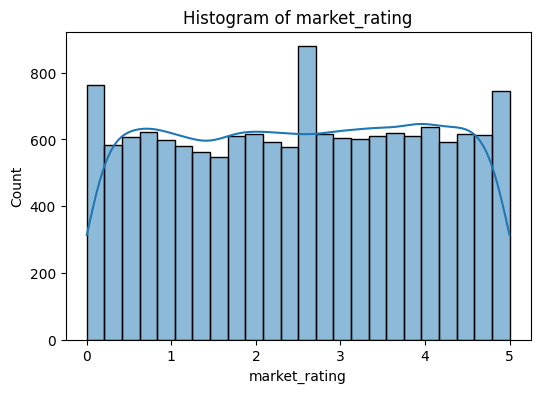

In [58]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

### Employee Count
**Insight:** The employee count distribution is fairly balanced across different ranges, indicating that the dataset contains companies of varying sizes.

### Founded Year
**Insight:** The founded year values are spread across multiple years, showing a mix of both established and recently founded companies.

### Customer Count
**Insight:** Customer count values are distributed across the dataset, suggesting diversity in the size of customer bases served by companies.

### Market Rating
**Insight:** Market ratings are fairly distributed, indicating variations in company performance and reputation.

### Annual Revenue (Million)
**Insight:** Annual revenue values cover a broad range, reflecting the presence of companies with different levels of financial performance.

### Profit Margin (%)
**Insight:** Profit margin percentages vary among companies, highlighting differences in profitability and operational efficiency.


## OUTLIER DETECTION

Outlier detection by Boxplot Analysis

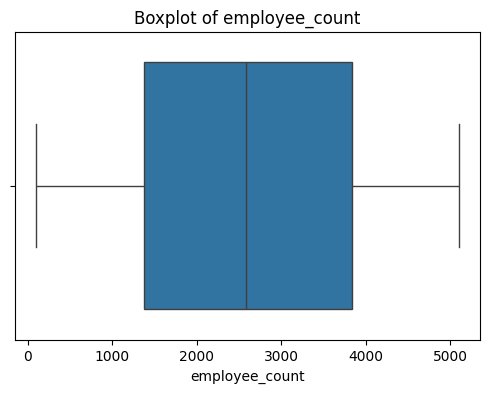

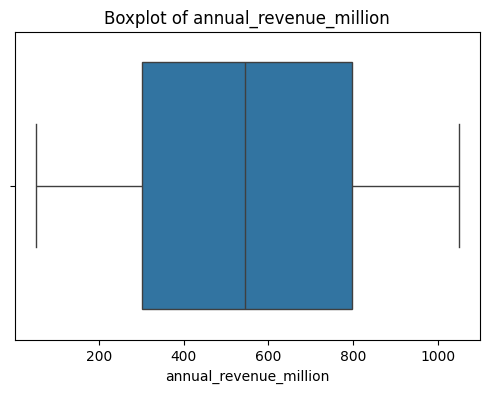

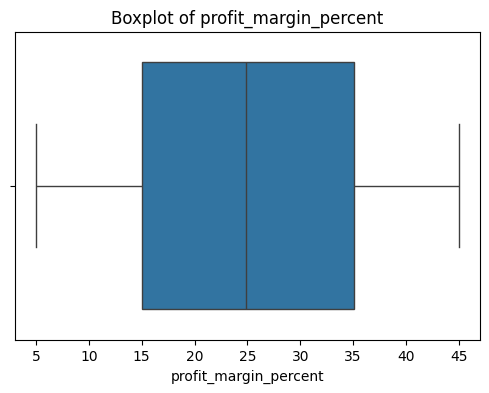

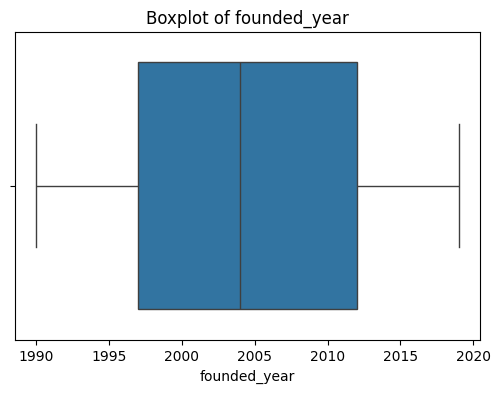

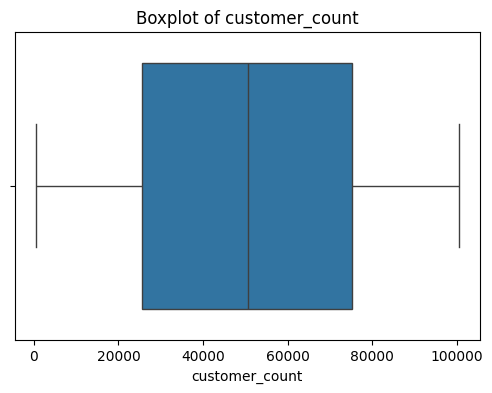

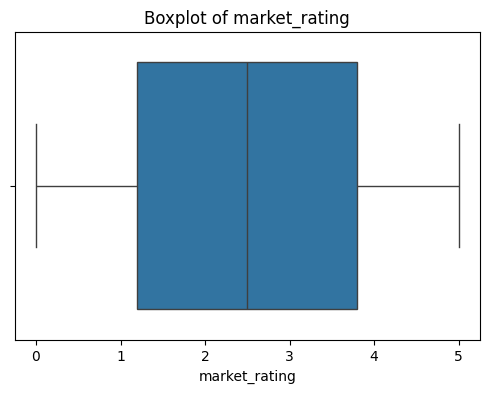

In [59]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Employee Count Boxplot
**Insight:** No significant outliers are observed in employee count, indicating a stable distribution of workforce sizes.

### Founded Year Boxplot
**Insight:** The founded year data does not contain major outliers, suggesting consistency in company age distribution.

### Customer Count Boxplot
**Insight:** Customer count values remain within a reasonable range without extreme observations.

### Market Rating Boxplot
**Insight:** Market ratings show a balanced spread and do not exhibit unusual values.

### Annual Revenue Boxplot
**Insight:** Revenue values are distributed evenly, with no significant outliers affecting the analysis.

### Profit Margin Boxplot
**Insight:** Profit margin percentages are relatively stable and do not show extreme variations.


# Outlier Detection

## Outlier Detection Using IQR Method

In [60]:
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

employee_count: 0 outliers
annual_revenue_million: 0 outliers
profit_margin_percent: 0 outliers
founded_year: 0 outliers
customer_count: 0 outliers
market_rating: 0 outliers


## Insight

No outliers were detected in any numerical variable using the Interquartile Range (IQR) method. Employee count, annual revenue, profit margin, founded year, customer count, and market rating all fall within the acceptable range. This indicates that the dataset is clean and does not contain extreme observations that could distort statistical analysis.

 Outlier Detection Using Z-Score

In [61]:
for col in numerical_cols:
    
    z_scores = np.abs(zscore(df[col]))

    outliers = df[z_scores > 3]

    print(f"{col}: {len(outliers)} outliers")

employee_count: 0 outliers
annual_revenue_million: 0 outliers
profit_margin_percent: 0 outliers
founded_year: 0 outliers
customer_count: 0 outliers
market_rating: 0 outliers


## Insight

No outliers were identified using the Z-Score method with a threshold of ±3. This confirms that the numerical variables are well-distributed and do not contain unusually extreme values. The consistency between IQR and Z-Score results further validates the quality and reliability of the dataset.

# CORRELATIONAL ANALYSIS

## Correlational Matrix

In [62]:
correlation_matrix = df[numerical_cols].corr()

correlation_matrix

,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
employee_count,1.000000,-0.002043,-0.002724,0.021180,-0.012431,-0.009352
annual_revenue_million,-0.002043,1.000000,-0.003120,-0.011840,-0.002673,0.014639
profit_margin_percent,-0.002724,-0.003120,1.000000,0.012379,0.011347,-0.006096
founded_year,0.021180,-0.011840,0.012379,1.000000,-0.008447,0.007468
customer_count,-0.012431,-0.002673,0.011347,-0.008447,1.000000,-0.004750
market_rating,-0.009352,0.014639,-0.006096,0.007468,-0.004750,1.000000


## Insight

The correlation values among all numerical variables are very close to zero, indicating extremely weak relationships between them. Employee count, annual revenue, profit margin, customer count, founded year, and market rating appear to operate independently within this dataset. No strong positive or negative correlation was observed, suggesting that changes in one variable do not significantly influence the others.

## Heatmap

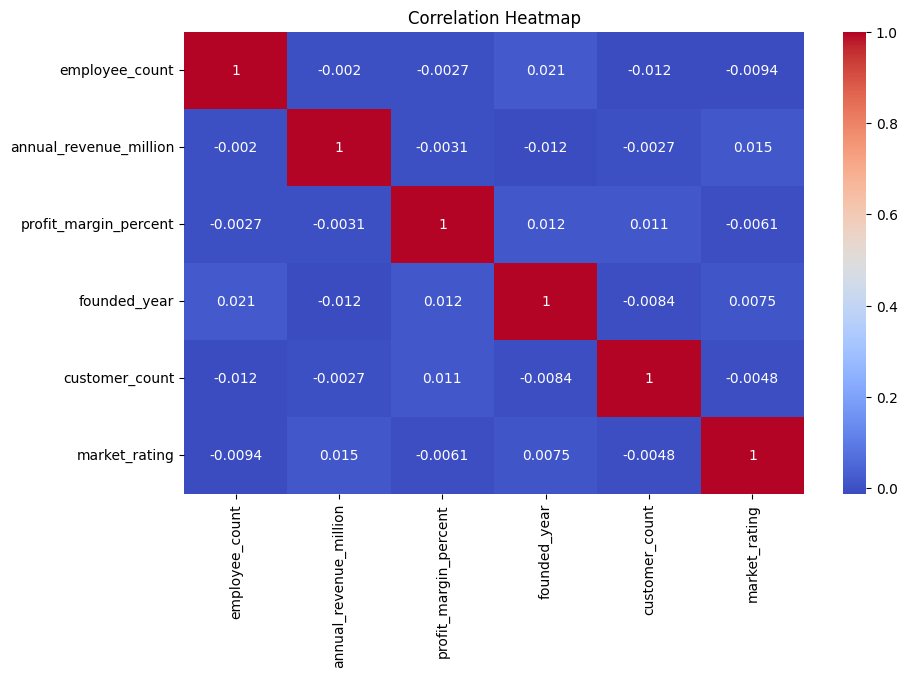

In [63]:
plt.figure(figsize=(10,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Insight

The heatmap visually confirms the absence of strong correlations among numerical variables. Most correlation coefficients are close to zero, indicating negligible linear relationships. Therefore, the business metrics in this dataset appear to be largely independent of one another.

# Categorical Variable Analysis

## Industry Distribution

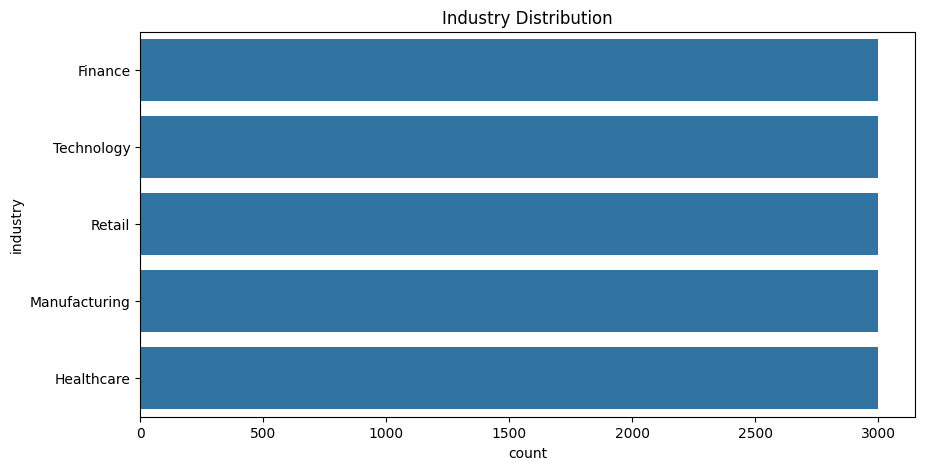

In [64]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='industry',
    data=df,
    order=df['industry'].value_counts().index
)

plt.title("Industry Distribution")
plt.show()



## Insight

The dataset contains five industries: Finance, Technology, Retail, Manufacturing, and Healthcare. Each industry has exactly 3,000 company records, indicating a perfectly balanced distribution across industries. This balanced structure helps prevent bias during comparative analysis.

## Country Distribution

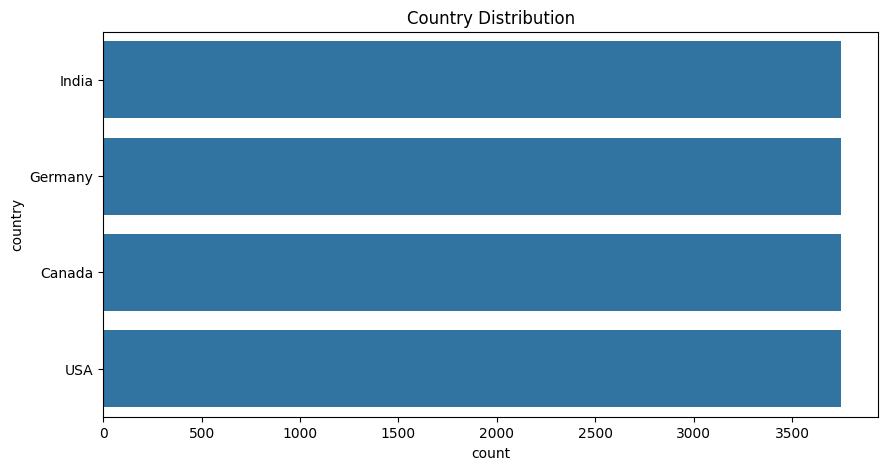

In [65]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='country',
    data=df,
    order=df['country'].value_counts().index
)

plt.title("Country Distribution")
plt.show()



## Insight

The dataset includes companies from four countries: India, Germany, Canada, and the USA. Each country contributes 3,750 records, resulting in an equal representation of geographical regions and enabling fair cross-country comparisons.

## Region Distribution 

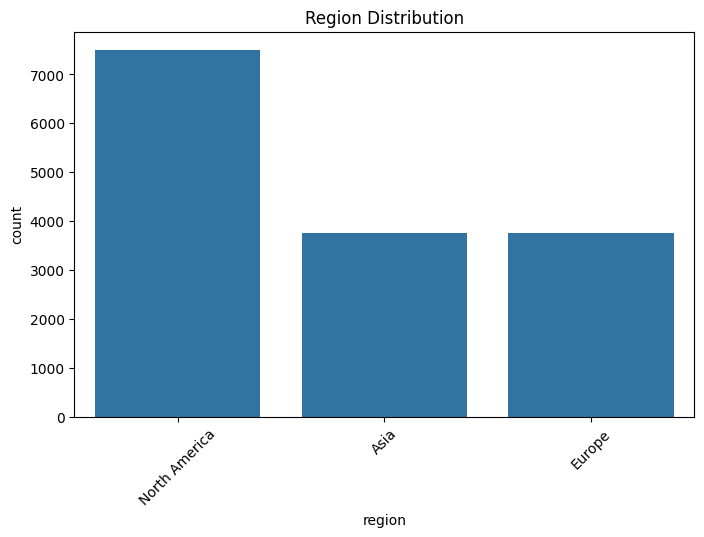

In [66]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='region',
    data=df,
    order=df['region'].value_counts().index
)

plt.title("Region Distribution")
plt.xticks(rotation=45)
plt.show()

## Insight

# BIVARIATE ANALYSIS

## Employee Count vs Revenue

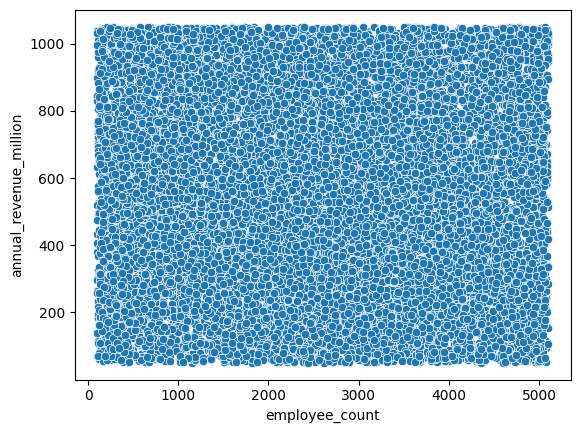

In [67]:
sns.scatterplot(
    x='employee_count',
    y='annual_revenue_million',
    data=df
)

plt.show()

## Insight

The scatter plot shows a random distribution of data points with no clear upward or downward trend. This indicates a very weak relationship between employee count and annual revenue, suggesting that larger workforce size does not necessarily guarantee higher revenue.

## Customer Count vs Revenue

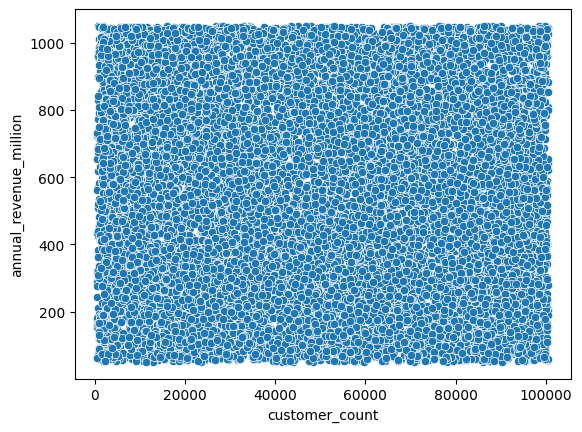

In [68]:
sns.scatterplot(
    x='customer_count',
    y='annual_revenue_million',
    data=df
)

plt.show()

## Insight

The scatter plot does not reveal any strong pattern or linear relationship between customer count and annual revenue. Companies with higher customer counts do not always generate proportionally higher revenue.

## Profit Margin vs Market Rating

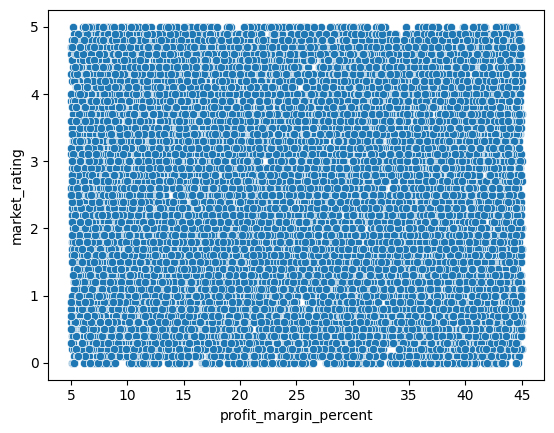

In [69]:
sns.scatterplot(
    x='profit_margin_percent',
    y='market_rating',
    data=df
)

plt.show()

## Insight

The scatter plot shows a dispersed pattern with no strong correlation between profit margin and market rating. This suggests that profitability and market perception operate relatively independently within the dataset.

## Revenue Distribution Across Industries

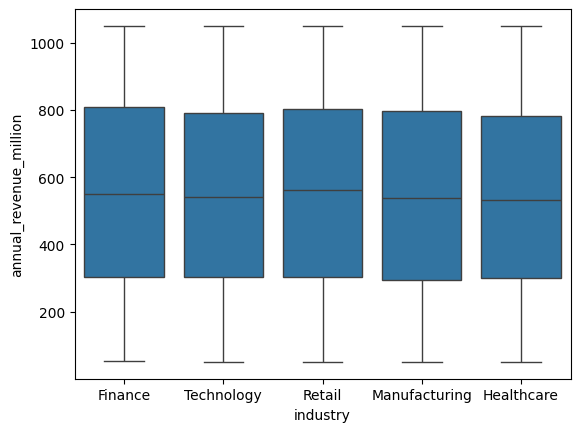

In [70]:
sns.boxplot(
    x='industry',
    y='annual_revenue_million',
    data=df
)

plt.show()

## Insight

The revenue distribution appears similar across all industries. Median values and spread are relatively consistent, indicating balanced revenue performance among Finance, Technology, Retail, Manufacturing, and Healthcare sectors.

## Profit Margin Across Industries

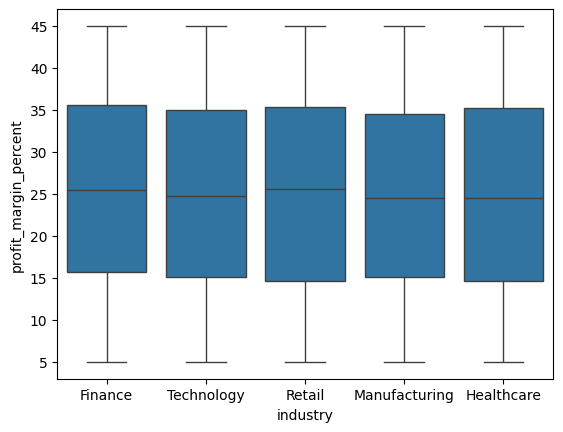

In [71]:
sns.boxplot(
    x='industry',
    y='profit_margin_percent',
    data=df
)

plt.show()

## Insight

Profit margins are distributed similarly across industries, with comparable median values and variability. No industry demonstrates significantly higher or lower profit margins than the others.}

## Market Rating Across Countries

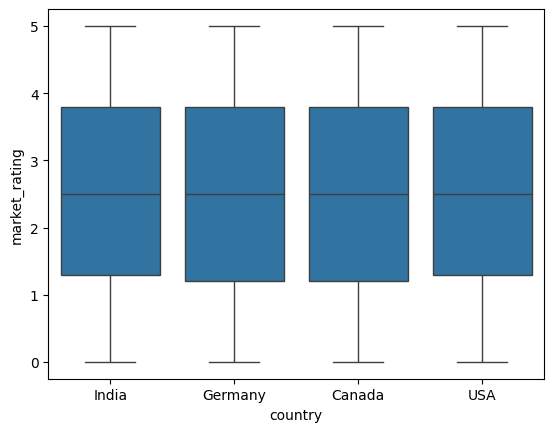

In [72]:
sns.boxplot(
    x='country',
    y='market_rating',
    data=df
)

plt.show()

## Insight

Market ratings show a similar distribution across all countries. The median ratings and spread remain consistent, indicating that customer perception is relatively uniform across different geographical markets.

## Employee Count Across Regions

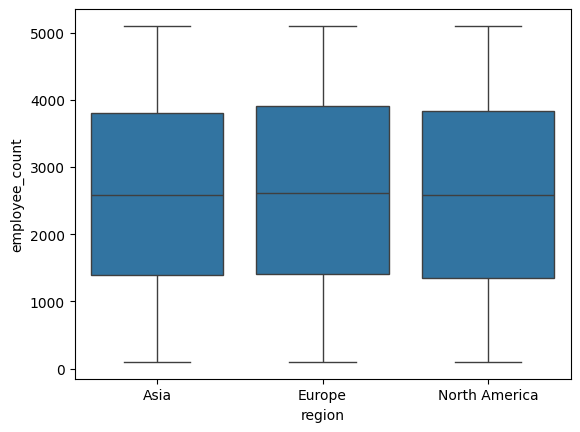

In [73]:
sns.boxplot(
    x='region',
    y='employee_count',
    data=df
)

plt.show()

## Insight

The distribution of employee count is highly similar across Asia, Europe, and North America. The median employee count in all three regions is around 2,500 employees, and the overall spread of the data is also comparable. This indicates that companies across different regions maintain similar workforce sizes, with no region showing a significantly larger or smaller employee base.

## Revenue Distribution Across Countries

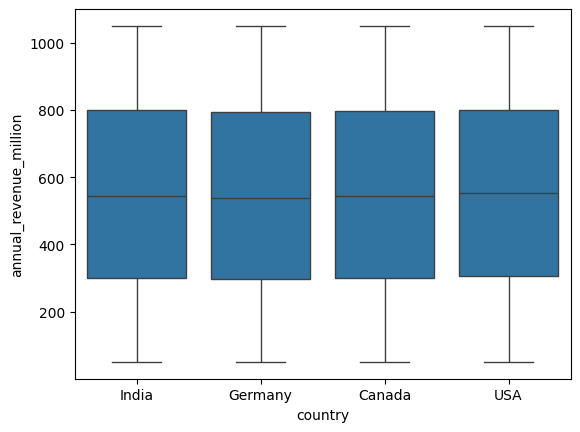

In [74]:
sns.boxplot(
    x='country',
    y='annual_revenue_million',
    data=df
)

plt.show()

## Insight

Annual revenue distributions are nearly identical across all countries. Similar median values and ranges indicate balanced revenue generation among companies operating in different countries.

# MULTIVARIATE ANALYSIS

## Pairplot

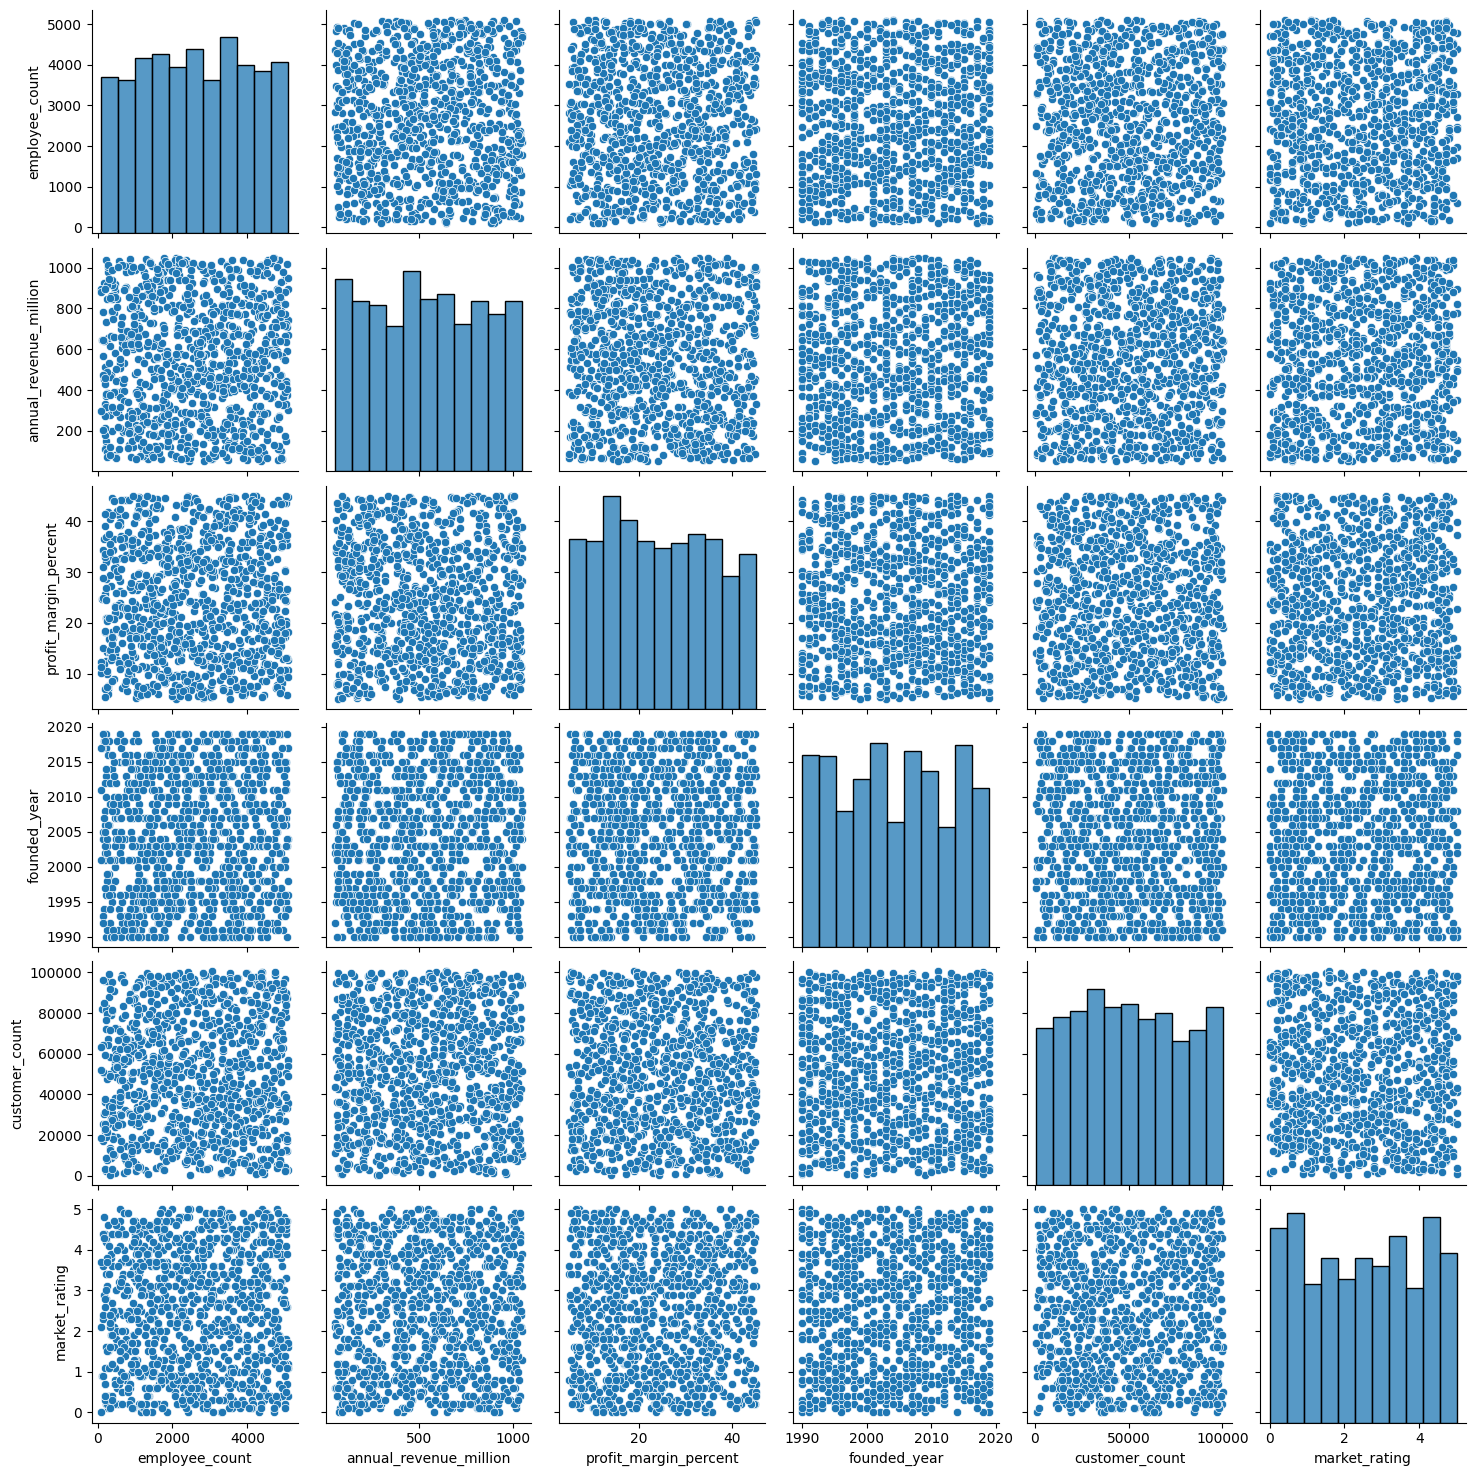

In [75]:
sns.pairplot(df[numerical_cols].sample(1000))
plt.show()

## Insight
The scatter plots do not show any strong linear relationships between variables. The random distribution of points confirms the weak correlations observed in the heatmap.

## Region vs Market Rating vs Profit Margin

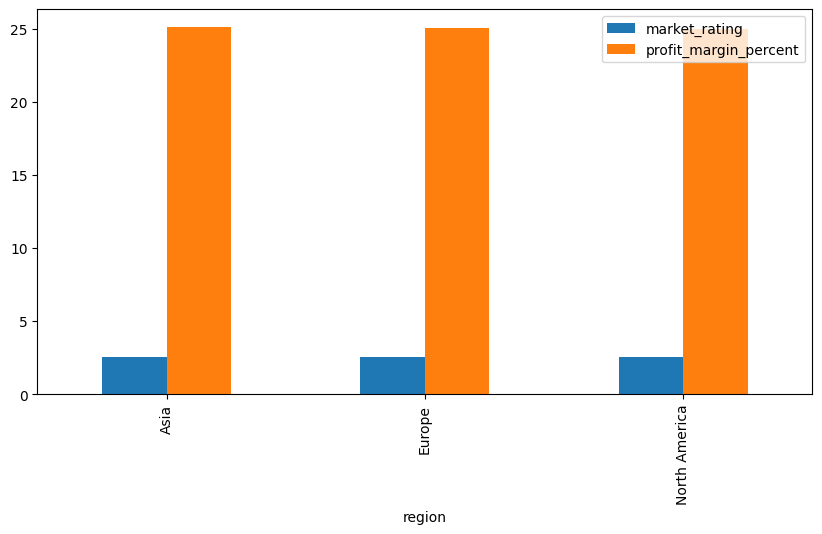

In [76]:
region_multi = df.groupby('region')[['market_rating','profit_margin_percent']].mean()

region_multi.plot(kind='bar', figsize=(10,5))

plt.show()


## Insight

The average market rating and profit margin remain relatively consistent across Asia, Europe, and North America. Although minor variations are observed, no region significantly outperforms the others. This indicates stable business performance and customer perception across different geographical regions.

## Country vs Customer Count vs Revenue

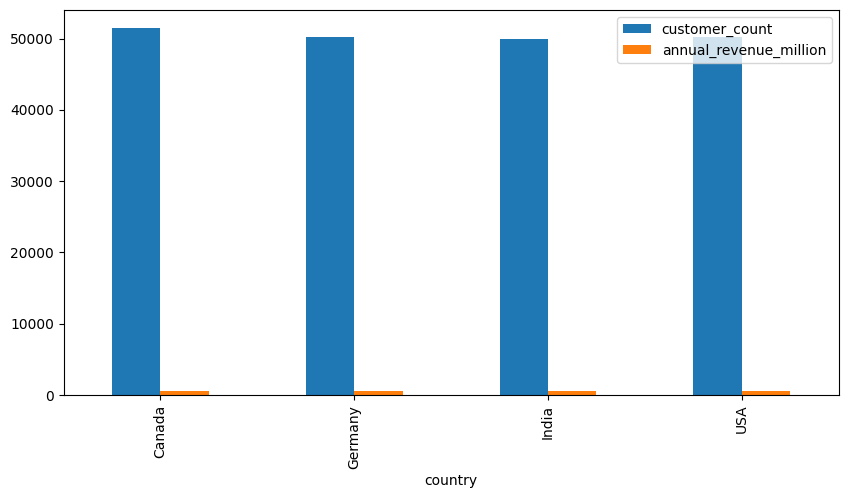

In [77]:
country_multi = df.groupby('country')[['customer_count','annual_revenue_million']].mean()

country_multi.plot(kind='bar', figsize=(10,5))

plt.show()

## Insight

Customer count is substantially higher than annual revenue values across all countries. The average customer base and revenue remain fairly balanced among Canada, Germany, India, and the USA, suggesting similar business performance across countries.

# BUSINESS INSIGHTS

## Average Revenue by Industry

In [78]:
df.groupby('industry')['annual_revenue_million'].mean().sort_values(ascending=False)

industry
Retail           556.609343
Finance          552.823690
Technology       550.198027
Manufacturing    545.575197
Healthcare       543.457277
Name: annual_revenue_million, dtype: float64

## Insight

Retail industry recorded the highest average annual revenue (556.61 million), followed closely by Finance and Technology. Healthcare showed the lowest average revenue among all industries. However, the difference in average revenue across industries is relatively small, indicating a balanced revenue distribution.

## Average Profit Margin by Industry

In [79]:
df.groupby('industry')['profit_margin_percent'].mean().sort_values(ascending=False)

industry
Finance          25.303310
Retail           25.085197
Technology       25.031367
Healthcare       24.878077
Manufacturing    24.762147
Name: profit_margin_percent, dtype: float64

## Insight

Finance industry achieved the highest average profit margin (25.30%), while Manufacturing reported the lowest (24.76%). Profit margins across all industries are very similar, suggesting consistent profitability levels throughout the dataset.

## Average Market Rating by Industry

In [80]:
df.groupby('industry')['market_rating'].mean().sort_values(ascending=False)

industry
Retail           2.554533
Healthcare       2.515967
Finance          2.512100
Technology       2.495200
Manufacturing    2.491100
Name: market_rating, dtype: float64

## Insight

Retail industry received the highest average market rating (2.55), indicating comparatively better customer perception and market performance. Manufacturing recorded the lowest rating, although the variation among industries is minimal.

## Average Revenue by Country

In [81]:
df.groupby('country')['annual_revenue_million'].mean().sort_values(ascending=False)

country
USA        552.907971
India      551.872211
Canada     548.375403
Germany    545.775243
Name: annual_revenue_million, dtype: float64

## Insight

Companies located in the USA generated the highest average revenue (552.91 million), followed closely by India. Germany recorded the lowest average revenue among the four countries, but revenue differences remain relatively small across countries.

## Average Revenue by Region

In [82]:
df.groupby('region')['annual_revenue_million'].mean().sort_values(ascending=False)

region
Asia             551.872211
North America    550.641687
Europe           545.775243
Name: annual_revenue_million, dtype: float64

## Insight

Asia achieved the highest average revenue (551.87 million), followed by North America. Europe recorded the lowest average revenue. The close revenue values across regions indicate a well-balanced global business distribution.

# Key Findings




1. The dataset contains 15,000 company records distributed evenly across five industries and four countries.

2. No missing values, duplicate records, or significant outliers were found in the dataset, indicating high data quality.

3. Skewness values were close to zero and kurtosis values were negative, suggesting approximately symmetric distributions with fewer extreme values.

4. Correlation analysis revealed very weak relationships among numerical variables, indicating that business metrics operate largely independently.

5. Revenue, profit margin, and market rating distributions were relatively similar across industries, countries, and regions.

6. Retail industry showed the highest average revenue, while Finance industry recorded the highest average profit margin.

7. Retail industry achieved the highest average market rating among all industries.

8. The USA generated the highest average revenue among the four countries analyzed.

9. Employee count, customer count, and revenue distributions remained balanced across geographical regions.

10. Overall business performance indicators showed consistency across industries, countries, and regions.

# Conclusion

This exploratory data analysis provided a comprehensive understanding of company performance across different industries, countries, and regions.

The dataset was clean, balanced, and free from significant outliers or missing values. Statistical analysis showed nearly symmetric distributions with minimal skewness and weak correlations among business variables. Comparative analysis across industries and regions revealed that most business metrics were distributed uniformly, indicating stable performance patterns.

Among industries, Retail demonstrated the highest average revenue, while Finance achieved the highest average profit margin. The USA recorded the highest average revenue among countries. Overall, the analysis suggests that company performance remains relatively balanced across different sectors and geographical locations.

The insights generated from this study can support strategic business decisions, benchmarking activities, and further predictive analytics projects.